<a href="https://colab.research.google.com/github/DeepanshuSharma1607/speech_classifier/blob/main/audio_class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("chrisfilo/urbansound8k")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'urbansound8k' dataset.
Path to dataset files: /kaggle/input/urbansound8k


In [ ]:
import os
folders=os.listdir(path)
print('Catergories found ',folders)

Catergories found  ['fold7', 'fold1', 'fold3', 'fold5', 'fold10', 'UrbanSound8K.csv', 'fold9', 'fold8', 'fold4', 'fold2', 'fold6']


In [ ]:
csv_file=os.path.join(path,'UrbanSound8K.csv')
csv_file

'/kaggle/input/urbansound8k/UrbanSound8K.csv'

In [ ]:
file_=os.path.join(path,'fold8')

In [ ]:
os.listdir(file_)

In [ ]:
file_=os.path.join(file_,'76266-2-0-50.wav')
file_

'/kaggle/input/urbansound8k/fold8/76266-2-0-50.wav'

In [ ]:
import matplotlib.pyplot as plt
%matplotlib inline

In [ ]:
import IPython.display as ipd
import librosa
import librosa.display

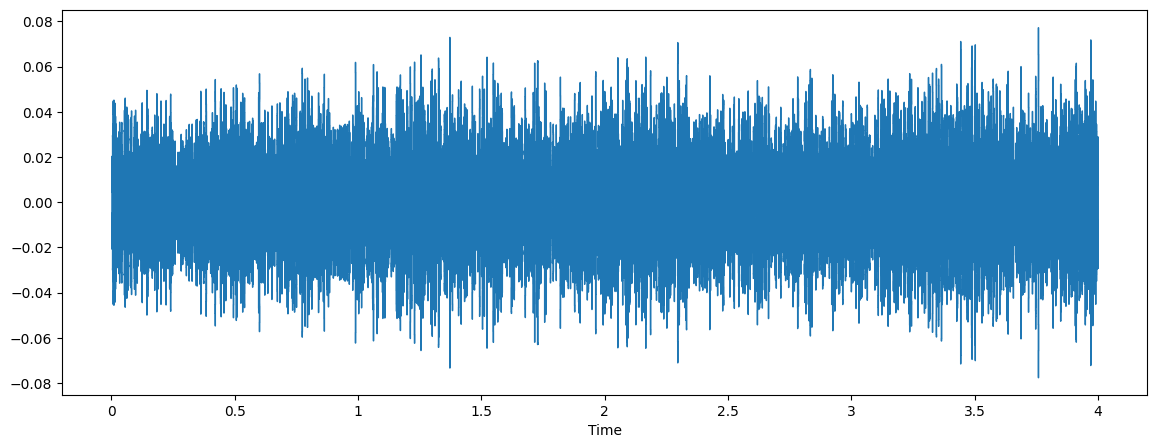

In [ ]:
plt.figure(figsize=(14,5))
data,sample_rate=librosa.load(file_)
librosa.display.waveshow(data,sr=sample_rate)
ipd.Audio(file_)

In [ ]:
sample_rate

22050

In [ ]:
data

array([ 0.00368305,  0.00523143,  0.00668722, ..., -0.00797574,
       -0.00763363, -0.00644841], dtype=float32)

In [ ]:
data.shape

(88200,)

In [ ]:
from scipy.io import wavfile as wav
wave_sample_rate,wave_audio=wav.read(file_)

In [ ]:
wave_sample_rate,wave_audio,wave_audio.shape

(44100,
 array([[ 387,  -65],
        [ 423,  -87],
        [ 411, -111],
        ...,
        [-354, -130],
        [-296, -106],
        [-266,  -48]], dtype=int16),
 (176400, 2))

In [ ]:
import pandas as pd

metadata=pd.read_csv(csv_file)
metadata.head()

,slice_file_name,fsID,start,end,salience,fold,classID,class
0,100032-3-0-0.wav,100032,0.0,0.317551,1,5,3,dog_bark
1,100263-2-0-117.wav,100263,58.5,62.500000,1,5,2,children_playing
2,100263-2-0-121.wav,100263,60.5,64.500000,1,5,2,children_playing
3,100263-2-0-126.wav,100263,63.0,67.000000,1,5,2,children_playing
4,100263-2-0-137.wav,100263,68.5,72.500000,1,5,2,children_playing


In [ ]:
metadata.describe()

,fsID,start,end,salience,fold,classID
count,8732.000000,8732.000000,8732.000000,8732.000000,8732.000000,8732.000000
mean,116033.493816,38.645409,42.253312,1.347000,5.385937,4.592877
std,57991.017218,74.292126,74.369669,0.476043,2.846820,2.894544
min,344.000000,0.000000,0.105962,1.000000,1.000000,0.000000
25%,69942.250000,3.000000,6.839398,1.000000,3.000000,2.000000
50%,118279.000000,10.376492,14.000000,1.000000,5.000000,4.000000
75%,166942.000000,35.131372,38.866979,2.000000,8.000000,7.000000
max,209992.000000,600.125356,604.125356,2.000000,10.000000,9.000000


In [ ]:
metadata.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8732 entries, 0 to 8731
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   slice_file_name  8732 non-null   object 
 1   fsID             8732 non-null   int64  
 2   start            8732 non-null   float64
 3   end              8732 non-null   float64
 4   salience         8732 non-null   int64  
 5   fold             8732 non-null   int64  
 6   classID          8732 non-null   int64  
 7   class            8732 non-null   object 
dtypes: float64(2), int64(4), object(2)
memory usage: 545.9+ KB


In [ ]:
metadata['class'].value_counts()

,count
class,
dog_bark,1000
children_playing,1000
air_conditioner,1000
street_music,1000
jackhammer,1000
engine_idling,1000
drilling,1000
siren,929
car_horn,429


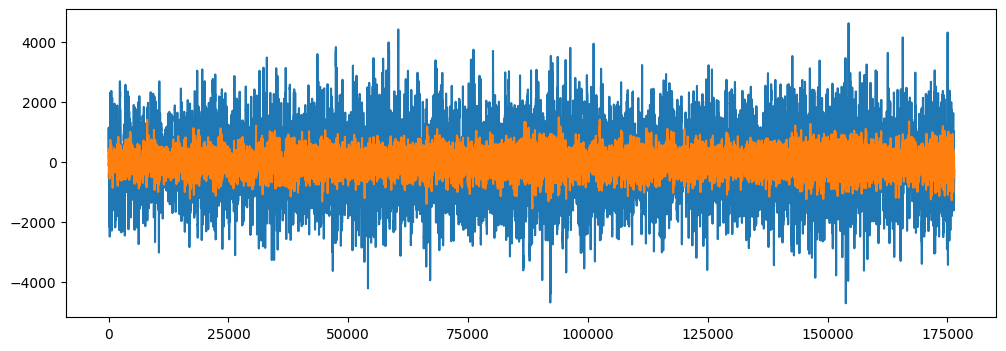

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.plot(wave_audio)

##Mel-Frequency Cepstral Coefficients
It summarize the frequency distribution across the window size,
so it is possible to analyse both the frequency and time character of the sound.
The audio representation will allow us to identify features for classification

In [ ]:
mfccs=librosa.feature.mfcc(y=data,sr=sample_rate
                           ,n_mfcc=40)
mfccs.shape

(40, 173)

In [ ]:
mfccs

array([[-350.52777   , -320.3767    , -324.02814   , ..., -293.99338   ,
        -283.4032    , -302.6997    ],
       [ 152.86053   ,  153.69002   ,  153.5896    , ...,  151.91104   ,
         157.0857    ,  149.75876   ],
       [   7.0570655 ,    1.2421646 ,   -7.0855923 , ...,  -28.113668  ,
         -31.280478  ,  -33.005627  ],
       ...,
       [  -8.331312  ,   -3.1231446 ,    2.378139  , ...,    1.3253465 ,
          -1.2249471 ,   -4.4485726 ],
       [  -9.389213  ,   -3.1537604 ,   -0.35183194, ...,   -9.913351  ,
          -5.191418  ,   -3.2362247 ],
       [   8.396354  ,    9.164386  ,    6.8483996 , ...,   -7.4005127 ,
           4.497596  ,   10.57005   ]], dtype=float32)

In [ ]:
import lazy_loader
import numpy as np
def feature_extractor(file):
  audio,sample_rate=librosa.load(file_name,res_type='soxr_hq')
  mfccs_features=librosa.feature.mfcc(y=audio,sr=sample_rate,n_mfcc=40)
  mfccs_scaled_feature=np.mean(mfccs_features.T,axis=0)
  return mfccs_scaled_feature


In [ ]:
from tqdm import tqdm
extracted_feature=[]
for index_num,row in tqdm(metadata.iterrows()):
  file_name=os.path.join(os.path.abspath(path),'fold'+str(row['fold'])+
                         '/',str(row['slice_file_name']))
  final_class_labels=row['class']
  data=feature_extractor(file_name)
  extracted_feature.append([data,final_class_labels])

3554it [02:39, 27.96it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1323
  warnings.warn(
8326it [06:06, 25.18it/s]/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1103
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/librosa/core/spectrum.py:266: UserWarning: n_fft=2048 is too large for input signal of length=1523
  warnings.warn(
8732it [06:22, 22.81it/s]


In [ ]:
extracted_feature_df=pd.DataFrame(extracted_feature,columns=['feature','class'])
extracted_feature_df.head()

,feature,class
0,"[-211.93698, 62.58122, -122.813156, -60.745296...",dog_bark
1,"[-417.00525, 99.336624, -42.995586, 51.073326,...",children_playing
2,"[-452.39316, 112.36253, -37.578075, 43.195866,...",children_playing
3,"[-406.47922, 91.19661, -25.043556, 42.784523, ...",children_playing
4,"[-439.63873, 103.86224, -42.658787, 50.690285,...",children_playing


In [ ]:
X=np.array(extracted_feature_df['feature'].tolist())
y=np.array(extracted_feature_df['class'].tolist())

In [ ]:
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder
labelencoder = LabelEncoder()
y=to_categorical(labelencoder.fit_transform(y))

In [ ]:
y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [ ]:
X.shape,y.shape

((8732, 40), (8732, 10))

In [ ]:
y.shape

(8732, 10)

In [ ]:
y

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [ ]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
X_train.shape,X_test.shape

((6985, 40), (1747, 40))

In [ ]:
y_train.shape,y_test.shape

((6985, 10), (1747, 10))

In [ ]:
import tensorflow
from tensorflow import keras
from tensorflow.keras.layers import Dense,Flatten,Dropout
from tensorflow.keras import Sequential

In [ ]:
model=Sequential([
    Dense(100,activation='relu',input_shape=(40,)),
    Dropout(0.5),
    Dense(200,activation='relu'),
    Dropout(0.5),
    Dense(100,activation='relu'),
    Dropout(0.5),
    Dense(10,activation='softmax')
])
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_8 (Dense)                 │ (None, 100)            │         4,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 200)            │        20,200 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 200)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 100)            │        20,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 45,410 (177.38 KB)

 Trainable params: 45,410 (177.38 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.callbacks import ModelCheckpoint
from datetime import datetime
checkpointer=ModelCheckpoint(
    filepath='saved_models/audio_classification.keras',
    verbose=1,save_best_only=True)
start=datetime.now()
history=model.fit(X_train,y_train,epochs=200,batch_size=32
                  ,validation_data=(X_test,y_test),
                  callbacks=[checkpointer])
dur=datetime.now()-start
print('Training end in ',dur)

Epoch 1/200
219/219 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1177 - loss: 21.7591
Epoch 1: val_loss improved from None to 2.28539, saving model to saved_models/audio_classification.keras

Epoch 1: finished saving model to saved_models/audio_classification.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.1171 - loss: 10.9963 - val_accuracy: 0.1191 - val_loss: 2.2854
Epoch 2/200
205/219 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1091 - loss: 2.7999
Epoch 2: val_loss improved from 2.28539 to 2.27819, saving model to saved_models/audio_classification.keras

Epoch 2: finished saving model to saved_models/audio_classification.keras
219/219 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1200 - loss: 2.6317 - val_accuracy: 0.1191 - val_loss: 2.2782
Epoch 3/200
214/219 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.1134 - loss: 2.3903
Epoch 3: val_loss improved from 2.27819 to 2.26961, saving model to saved_models/audio_classification.keras

Epoch 3: finished saving mode

In [ ]:
test_acc=model.evaluate(X_test,y_test,verbose=0)
test_acc

[0.6982778310775757, 0.8008013963699341]

In [ ]:
file_name=os.path.join(path,'fold2')
os.listdir(file_name)

['76086-4-0-58.wav',
 '76086-4-0-3.wav',
 '203929-7-7-14.wav',
 '185800-4-2-1.wav',
 '98202-9-1-27.wav',
 '4201-3-0-0.wav',
 '159747-8-0-0.wav',
 '182739-2-0-17.wav',
 '76091-6-2-0.wav',
 '169098-7-4-5.wav',
 '71080-4-0-0.wav',
 '27349-3-2-1.wav',
 '123688-8-0-17.wav',
 '77751-4-6-0.wav',
 '194841-9-0-48.wav',
 '69883-3-0-20.wav',
 '109703-2-0-134.wav',
 '72567-1-4-0.wav',
 '102871-8-0-10.wav',
 '74507-0-0-16.wav',
 '4201-3-1-0.wav',
 '197320-6-12-0.wav',
 '72567-1-2-4.wav',
 '102871-8-0-15.wav',
 '203929-7-3-3.wav',
 '158597-2-0-3.wav',
 '72567-1-3-0.wav',
 '100652-3-0-2.wav',
 '132073-1-4-0.wav',
 '203929-7-9-0.wav',
 '77751-4-0-1.wav',
 '189991-0-0-5.wav',
 '155129-1-0-0.wav',
 '58202-1-0-0.wav',
 '189023-0-0-11.wav',
 '74507-0-0-1.wav',
 '159750-8-0-3.wav',
 '196063-2-0-0.wav',
 '109703-2-0-153.wav',
 '143970-5-0-0.wav',
 '96475-9-0-6.wav',
 '174994-3-0-2.wav',
 '39970-9-0-142.wav',
 '201652-5-4-0.wav',
 '106015-5-0-2.wav',
 '203929-7-9-12.wav',
 '189023-0-0-10.wav',
 '152908-5-0-7

In [ ]:
file_name=os.path.join(path,'fold2','196063-2-0-1.wav')
file_name

'/kaggle/input/urbansound8k/fold2/196063-2-0-1.wav'

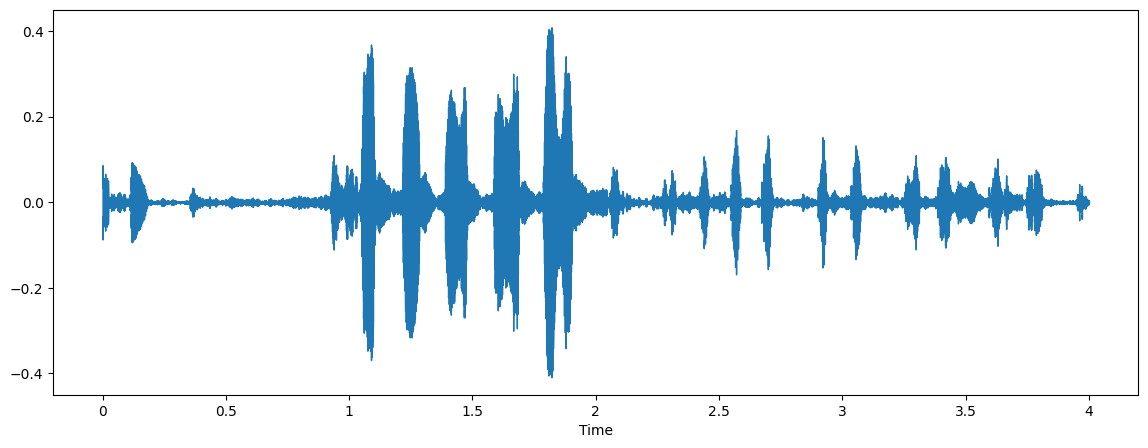

In [ ]:
plt.figure(figsize=(14,5))
data,sample_rate=librosa.load(file_name)
librosa.display.waveshow(data,sr=sample_rate)
ipd.Audio(file_name)

In [ ]:
f_e=feature_extractor(file_name)

In [ ]:
pred_input=f_e.reshape(1,-1)
pred=model.predict(pred_input)
pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


array([[9.42677958e-04, 8.10594764e-03, 7.12039828e-01, 1.01065487e-01,
        2.47716010e-02, 1.20947985e-02, 1.06092349e-01, 3.53766991e-05,
        3.75640718e-03, 3.10953856e-02]], dtype=float32)

In [ ]:
predicted_class_index = np.argmax(pred, axis=1)
pred_label = labelencoder.inverse_transform(predicted_class_index)
pred_label

array(['children_playing'], dtype='<U16')

In [ ]:
# Print the classes in their encoded sequence
for index, label in enumerate(labelencoder.classes_):
    print(f"{index}: {label}")

0: air_conditioner
1: car_horn
2: children_playing
3: dog_bark
4: drilling
5: engine_idling
6: gun_shot
7: jackhammer
8: siren
9: street_music
